In [1]:
#

####So one of the things in the dataset of 275000+ european card holders is that no names of the coulmns are given, so it's basically V1, V2 etc. Hence we cannot interpreet anything from the Column names it self

In [2]:
#Loading the dataset from Kaggle
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "creditcard.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mlg-ulb/creditcardfraud",
  file_path,
)
df.head()

/tmp/ipython-input-2-3736622719.py:7: DeprecationWarning: load_dataset is deprecated and will be removed in a future version.
  df = kagglehub.load_dataset(


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


##Now before getting in to the Data preprocessing step it is good to have some background of the data and the problem statement
#####It is important that credit card companies are able to recognize fraudulent credit card transactions so that customers are not charged for items that they did not purchase. So basically out of 275000+ transaction data (with labels of fraud and non fraud) of the cutomers we have to filter out those data points which represents anomaly/fraud.



In [3]:
df.info()
#no null values which is a good thing

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


##About the Data
#####The dataset contains transactions made by credit cards in September 2013 by European cardholders.
This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions. 0 in class implies => Non fraud and 1 = Fraud

It contains only numerical input variables which are the result of a PCA transformation. Unfortunately, due to confidentiality issues, we cannot provide the original features and more background information about the data. Features V1, V2, … V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'. Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature 'Amount' is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning. Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.

Given the class imbalance ratio, we recommend measuring the accuracy using the Area Under the Precision-Recall Curve (AUPRC). Confusion matrix accuracy is not meaningful for unbalanced classification.

In [5]:
# another important thing to note is that all the features have been scaled except time and amount which obviusly shouldn't have been scaled

In [6]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [7]:
#which implies
print((df['Class'].value_counts()[0]/(df['Class'].value_counts()[0]+df['Class'].value_counts()[1]))*100, "% of the non fraud")
print((df['Class'].value_counts()[1]/(df['Class'].value_counts()[0]+df['Class'].value_counts()[1]))*100, "% of the fraud")

99.82725143693798 % of the non fraud
0.1727485630620034 % of the fraud


#####Notice how imbalanced is our dataset! Most of the transactions are non-fraud. If we use this dataframe as the base for our predictive models and analysis we might get a lot of errors and our algorithms will probably overfit since it will "assume" that most transactions are not fraud. But we don't want our model to assume, we want our model to detect patterns that give signs of fraud. So we would have to perform fome pre liminary analysis to mitigate this issue

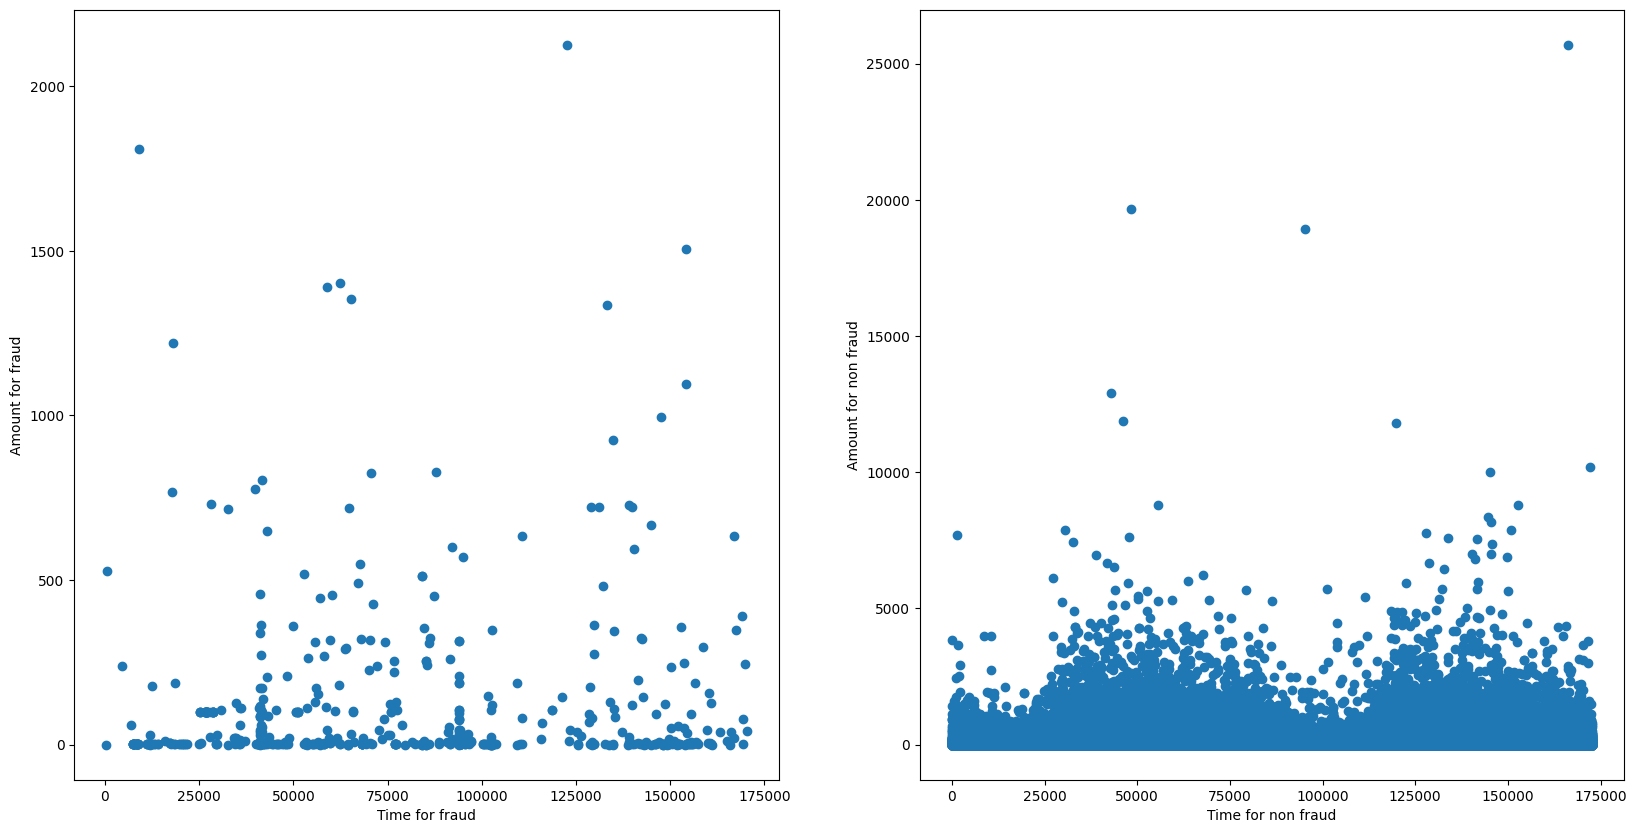

In [8]:
import matplotlib.pyplot as plt
data1 = df[df['Class']==1]
data2 = df[df['Class']==0]
# data1.head()
plt.figure(figsize = (20,10))
plt.subplot(1,2,1)
plt.scatter(x = data1['Time'],y = data1['Amount'])
plt.xlabel('Time for fraud')
plt.ylabel('Amount for fraud')
plt.subplot(1,2,2)
plt.scatter(x = data2['Time'],y = data2['Amount'])
plt.xlabel('Time for non fraud')
plt.ylabel('Amount for non fraud')
plt.show()

In [9]:
print(len(data1[data1['Amount'] > 10000]), "fraud at big amounts")
print(len(data2[data2['Amount'] > 10000]) ,"non fraud at big amounts")

0 fraud at big amounts
7 non fraud at big amounts


#####Now, another insighful data from the above graph. So, a general convention we might assume ki the transactions which are suddenly of very big amounts is likely to be fraud, but here you see it is almost opposite, non fraud classes include much much higer value stouching 25000 but fraud classes barely touch 2500

In [10]:
#So first of all we need to remove the imbalanced dataset problem as any classification model trained on the original dataset will likeyly be false and will wive most of the classes to be 0 = Non fraud

##Re - Sampling
#####Essentially this is a method that will process the data to have an approximate 50-50 ratio.
One way to achieve this is by OVER-sampling, which is adding copies of the under-represented class (better when you have little data)
Another is UNDER-sampling, which deletes instances from the over-represented class (better when he have lot's of data)
#####In this notebook, we will use traditional UNDER-sampling.
The way we will under sample the dataset will be by creating a 50/50 ratio. This will be done by randomly selecting "x" amount of sample from the majority class, being "x" the total number of records with the minority class.




In [20]:
import numpy as np
import seaborn as sns

# Number of data points in the minority class
number_records_fraud = len(df[df.Class == 1])
fraud_indices = np.array(df[df.Class == 1].index)
normal_indices = np.array(df[df.Class == 0].index)

# Out of the indices we picked, randomly select "x" number whre x = (number_records_fraud)
random_normal_indices = np.random.choice(normal_indices, number_records_fraud, replace = False)
# random_normal_indices = np.array(random_normal_indices)

# Appending the 2 indices
under_sample_indices = np.concatenate([fraud_indices,random_normal_indices])

# Under sample dataset
under_sample_df = df.iloc[under_sample_indices,:]
under_sample_df = under_sample_df.sample(frac=1).reset_index(drop=True) #shuffling the dataset


x_undersample = under_sample_df.iloc[:, under_sample_df.columns != 'Class']
y_undersample = under_sample_df.iloc[:, under_sample_df.columns == 'Class']

# Showing ratio
print("Percentage of normal transactions: ", len(under_sample_df[under_sample_df.Class == 0])/len(under_sample_df))
print("Percentage of fraud transactions: ", len(under_sample_df[under_sample_df.Class == 1])/len(under_sample_df))
print("Total number of transactions in resampled df: ", len(under_sample_df))

#now obviusly the no. of fraud cases = 492 so since we are selecting same no. of fraud cases => total cases = 492*2 = 984

Percentage of normal transactions:  0.5
Percentage of fraud transactions:  0.5
Total number of transactions in resampled df:  984


In [12]:
y_undersample

,Class
0,1
1,1
2,1
3,0
4,1
...,...
979,0
980,0
981,1
982,1


In [13]:
#true dataset
x_original = df.iloc[:, df.columns != 'Class']
y_original = df.iloc[:, df.columns == 'Class']
x_original

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00


#####One more thing that can be done in the data preprocessing pipeline is to observe the data using a correlation matrix
This will help to remove reduntant features as well as show the dependence of the target y with the columns

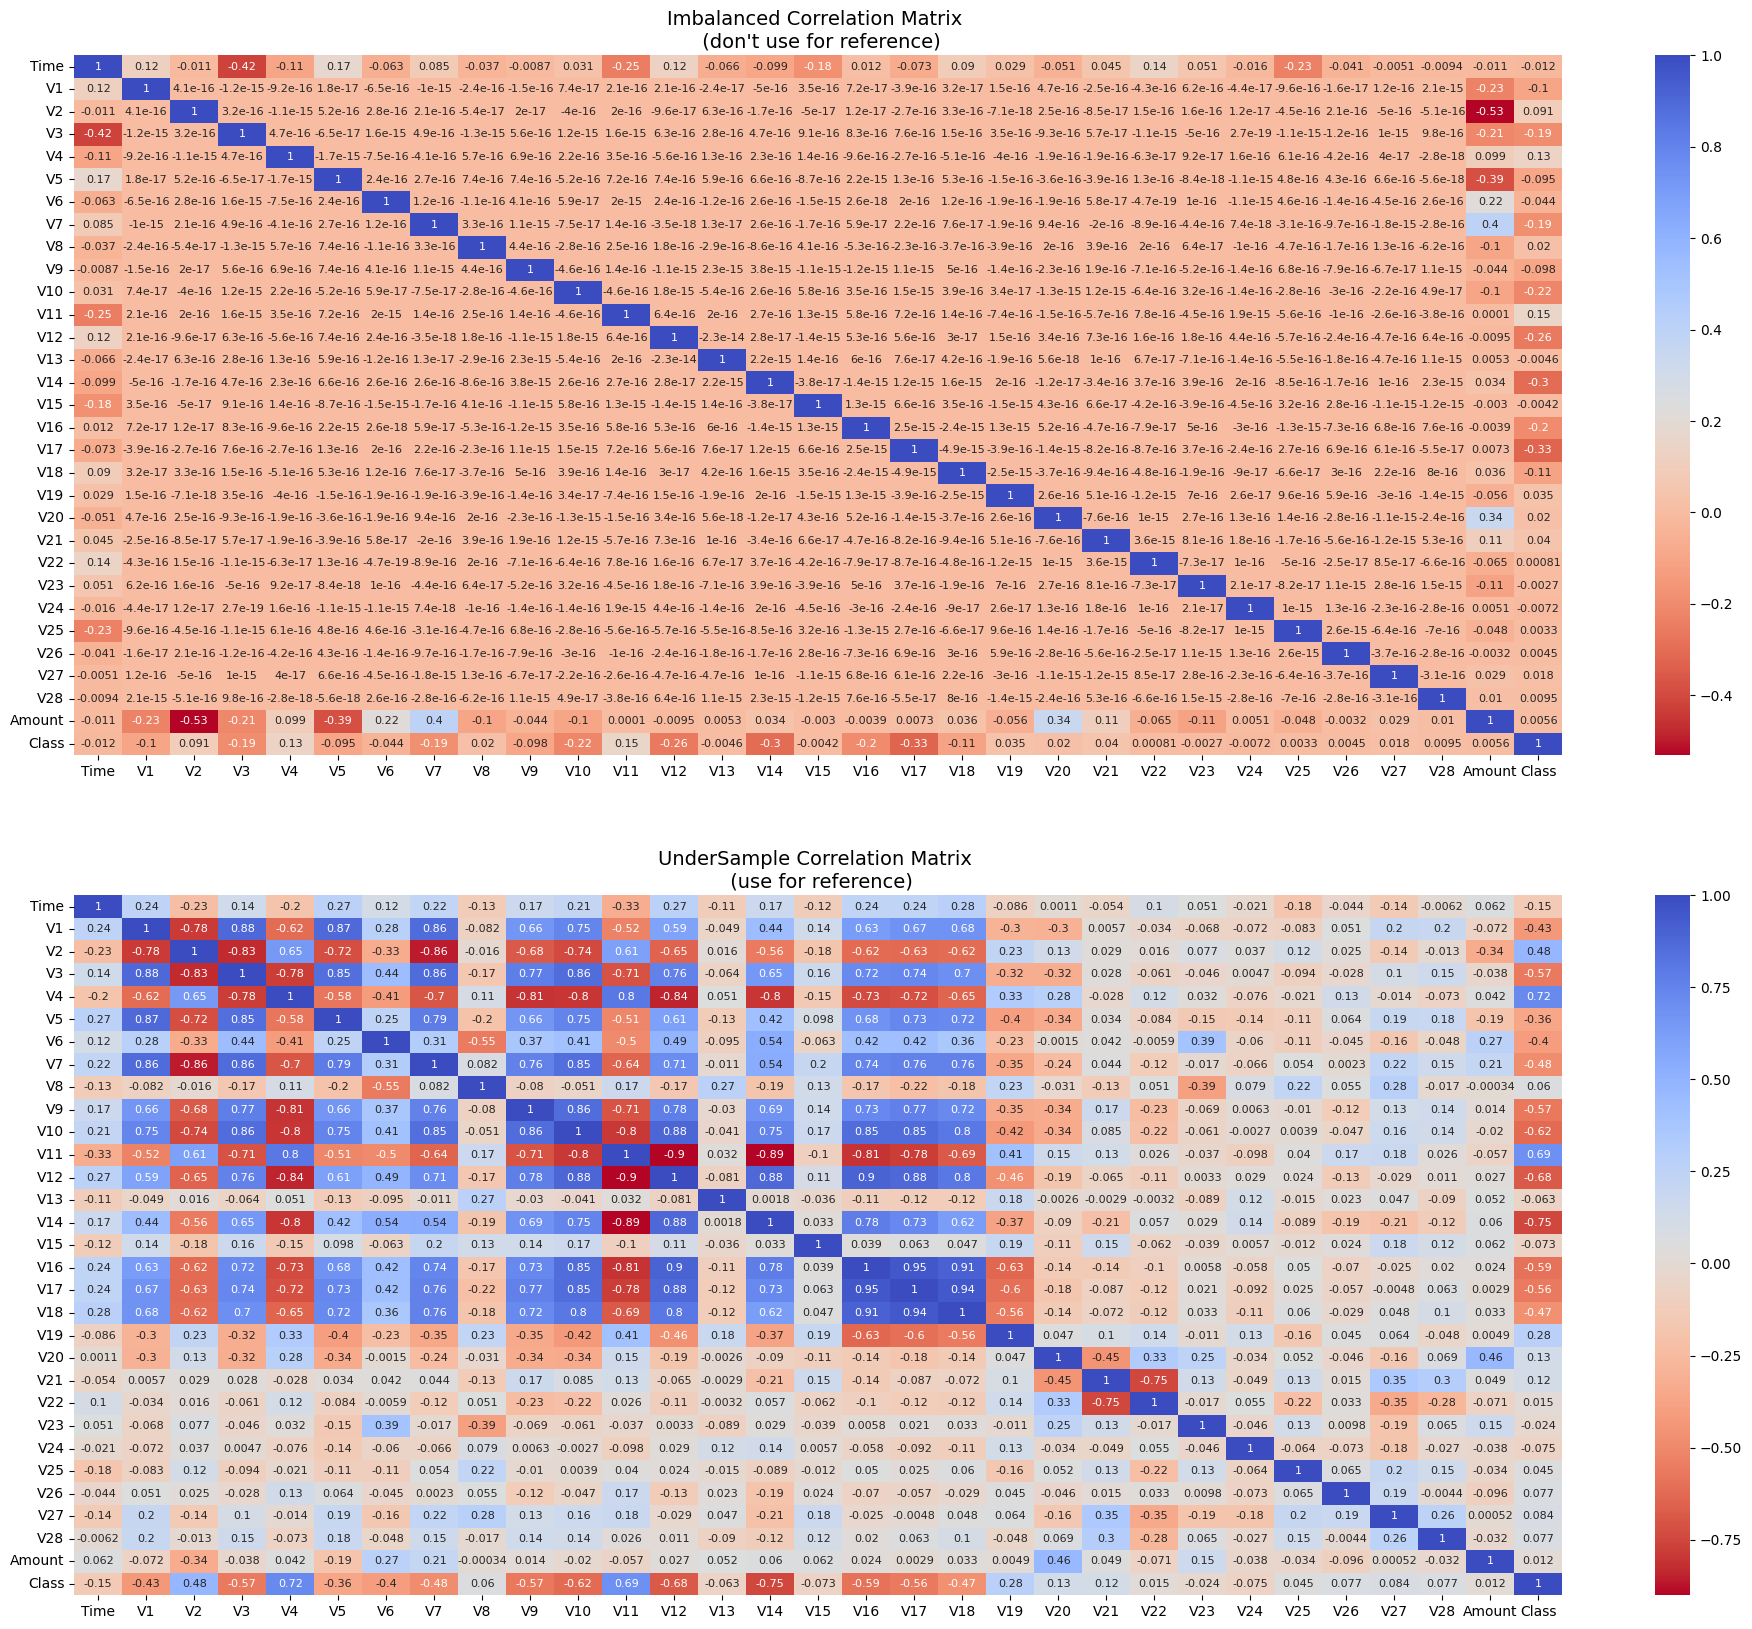

In [14]:
f, (ax1, ax2) = plt.subplots(2, 1, figsize=(24,20))

# Entire DataFrame
corr = df.corr()
sns.heatmap(corr,annot = True, cmap='coolwarm_r', annot_kws={'size':8}, ax=ax1)
ax1.set_title("Imbalanced Correlation Matrix \n (don't use for reference)", fontsize=14)


under_sample_corr = under_sample_df.corr()
sns.heatmap(under_sample_corr,annot = True, cmap='coolwarm_r', annot_kws={'size':8}, ax=ax2)
ax2.set_title('UnderSample Correlation Matrix \n (use for reference)', fontsize=14)
plt.show()

##Some Important Points
####1. The complete original df correlation matrix is not able to tell any relation between the features, on the other hand the balanced dataset reveals a lot into that area
####2. This happens because when you compute correlations across the entire dataset:

#####The correlations are dominated by the majority class.
#####Minority class samples have little effect on the correlation values.
#####This creates cleaner-looking correlation structures — because most of the data is more "uniform" (from the same class).

####3. Inferences from the correlation matrix
#####a. Features like V8, V22, V23, V25 they are almost neglegibly correlated with the class --> but that does not mean ki we have to remove them because they might carry some non linear dependencies which we'll see when we run some non linear models like LightGBM, XGBoost etc.
If at tahat time removing them does not show a significant deviation into the results they we can probably safely remove them
#####b. V2, V4, V11 and V19 have a high +ve correlation with the class => these features being high --> fraud transaction
#####c. On the other hand V17, V14, V12 and V10 are negative correlated with the class => these features being low --> fraud transaction

In [15]:
#Now, theer are a lot of features present in the dataset, we might want to run TSne to analyse the data into lower dimensions
# we'll be running TSNE with imbalanced and well as the resampled dataset to visualise in a better way


In [16]:
from sklearn.manifold import TSNE
import time
# T-SNE Implementation on undersample dataset
t0 = time.time()
x_undersample_reduced_tsne = TSNE(n_components=2,perplexity = 50,max_iter = 4000).fit_transform(x_undersample.values)
t1 = time.time()
print("T-SNE took {:.2} s".format(t1 - t0))

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


T-SNE took 3.9e+01 s


In [17]:
# # T-SNE Implementation on original dataset - taking a lot lot time - not feasible - better to visualise on the undersample
# t0 = time.time()
# x_original_reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(x_original.values)
# t1 = time.time()
# print("T-SNE took {:.2} s".format(t1 - t0))

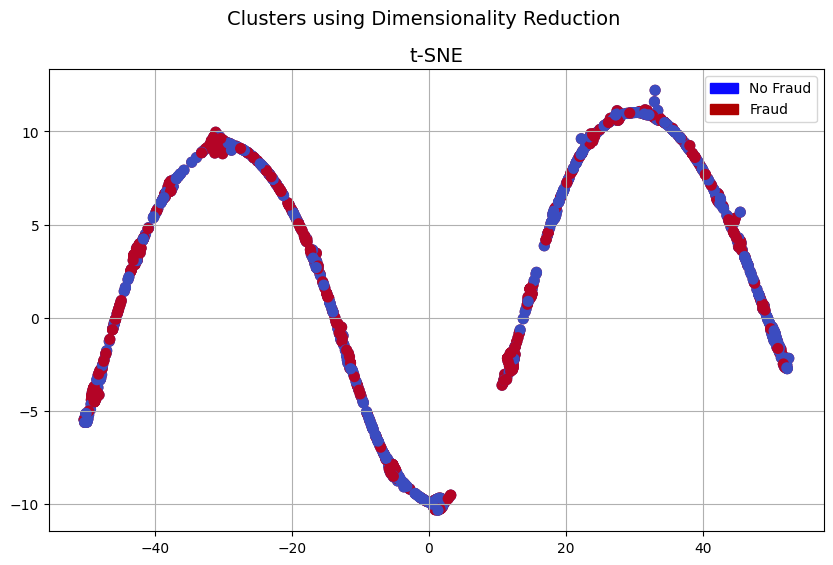

In [18]:
import matplotlib.patches as mpatches
f, ax = plt.subplots(1, 1, figsize=(10,6))
# labels = ['No Fraud', 'Fraud']
f.suptitle('Clusters using Dimensionality Reduction', fontsize=14)


blue_patch = mpatches.Patch(color='#0A0AFF', label='No Fraud')
red_patch = mpatches.Patch(color='#AF0000', label='Fraud')


# t-SNE scatter plot
ax.scatter(x_undersample_reduced_tsne[:,0], x_undersample_reduced_tsne[:,1], c=(y_undersample == 0).astype(int).values, cmap='coolwarm', label='No Fraud', linewidths=2)
ax.scatter(x_undersample_reduced_tsne[:,0], x_undersample_reduced_tsne[:,1], c=(y_undersample == 1).astype(int).values, cmap='coolwarm', label='Fraud', linewidths=2)
ax.set_title('t-SNE', fontsize=14)

ax.grid(True)

ax.legend(handles=[blue_patch, red_patch])


####So the above graph obviously indicates that we have done something wrong throughout our process because whatever iter or perpliexity you keep, the graph is almost on the same line
####That problem is not scaling the amount and time features, all the coloumns must be properly scaled before performing TSNE

In [21]:
from sklearn.preprocessing import StandardScaler, RobustScaler
std_scaler = StandardScaler()
rob_scaler = RobustScaler()

x_undersample['scaled_amount'] = rob_scaler.fit_transform(x_undersample['Amount'].values.reshape(-1,1))
x_undersample['scaled_time'] = rob_scaler.fit_transform(x_undersample['Time'].values.reshape(-1,1))

x_undersample.drop(['Time','Amount'], axis=1, inplace=True)

In [22]:
x_undersample

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,scaled_amount,scaled_time
0,1.531834,-1.045437,0.112258,-1.626421,-1.122097,-0.241173,-1.048624,-0.034286,-2.001933,1.619482,...,-0.219676,-0.288428,-0.077581,-0.528492,0.456481,-0.171462,0.022823,0.001974,-0.048285,-0.352001
1,0.062129,0.505173,-0.627162,-0.368315,-0.087553,-0.007318,0.028750,0.510532,0.454013,-1.269957,...,0.347979,0.882262,0.256754,0.214018,-0.801285,0.471939,-0.088292,-0.009086,0.711608,0.461058
2,-14.970346,8.401421,-16.867238,8.252334,-13.565130,-2.782438,-14.263735,9.643419,-7.701499,-14.226698,...,2.714045,-0.101355,-0.439666,0.519514,0.789328,0.064357,-1.621386,-1.104819,2.566195,-0.477712
3,1.935438,-0.233534,-2.013135,0.382241,0.222694,-0.765662,0.026925,-0.088280,1.296972,-0.876071,...,-0.265136,-0.755954,0.151284,0.297667,-0.087279,-0.105949,-0.033343,-0.007623,0.502153,0.500749
4,-3.606504,-4.584872,2.069156,-0.498062,0.374863,-0.781168,-0.309687,0.236464,-0.135938,-0.238239,...,0.527219,0.064784,1.547728,0.001992,0.681670,-0.323381,-0.132670,-0.003227,5.402290,-0.334139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
979,1.894036,1.905806,-3.515730,4.508913,2.044466,-1.420468,1.057480,-0.281157,-1.832604,-0.628463,...,-0.144713,-0.310108,-0.101530,-0.414960,0.376597,0.150778,-0.013712,0.048084,-0.177788,0.725671
980,-0.866857,-0.213176,3.187904,-1.315219,-1.351894,0.425969,-0.800879,0.486906,0.142817,-0.366636,...,0.191263,0.949007,-0.327687,0.453716,0.432803,-0.102410,0.361419,0.130250,-0.160156,-0.173913
981,-0.647836,0.637668,1.233701,-0.913156,0.824115,0.530063,0.750077,0.191156,-0.002213,-1.003307,...,-0.409696,-0.958744,-0.509786,-1.064019,0.702727,0.564815,-0.033463,0.016275,-0.190150,0.669728
982,-2.006582,3.676577,-5.463811,7.232058,-1.627859,-0.996755,-4.299833,2.268867,-3.651067,-4.400930,...,0.713907,-0.063868,0.167947,-0.449864,0.023702,0.536905,0.485864,-0.042393,-0.190150,0.696112


In [23]:
from sklearn.manifold import TSNE
import time
# T-SNE Implementation on undersample dataset
t0 = time.time()
x_undersample_reduced_tsne = TSNE(n_components=2,perplexity = 50,max_iter = 4000).fit_transform(x_undersample.values)
t1 = time.time()
print("T-SNE took {:.2} s".format(t1 - t0))

T-SNE took 4.7e+01 s


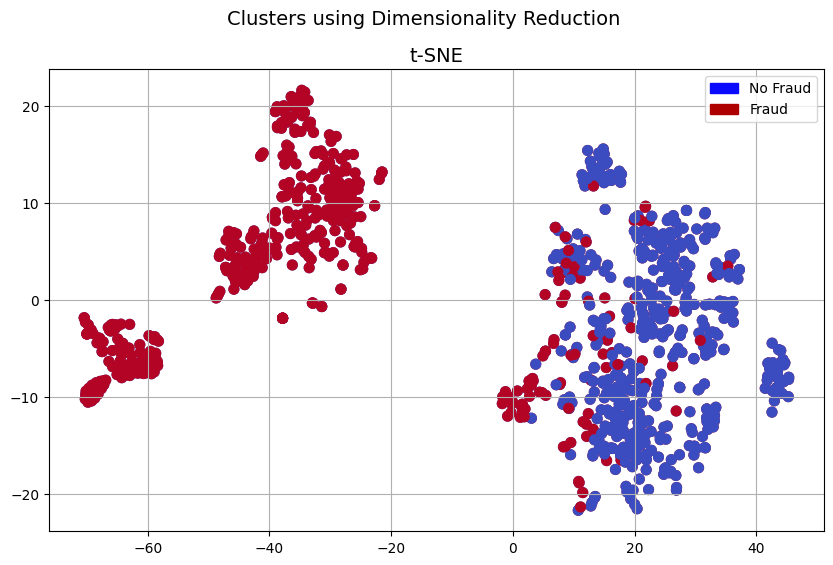

In [24]:
import matplotlib.patches as mpatches
f, ax = plt.subplots(1, 1, figsize=(10,6))
# labels = ['No Fraud', 'Fraud']
f.suptitle('Clusters using Dimensionality Reduction', fontsize=14)


blue_patch = mpatches.Patch(color='#0A0AFF', label='No Fraud')
red_patch = mpatches.Patch(color='#AF0000', label='Fraud')


# t-SNE scatter plot
ax.scatter(x_undersample_reduced_tsne[:,0], x_undersample_reduced_tsne[:,1], c=(y_undersample == 0).astype(int).values, cmap='coolwarm', label='No Fraud', linewidths=2)
ax.scatter(x_undersample_reduced_tsne[:,0], x_undersample_reduced_tsne[:,1], c=(y_undersample == 1).astype(int).values, cmap='coolwarm', label='Fraud', linewidths=2)
ax.set_title('t-SNE', fontsize=14)

ax.grid(True)

ax.legend(handles=[blue_patch, red_patch])


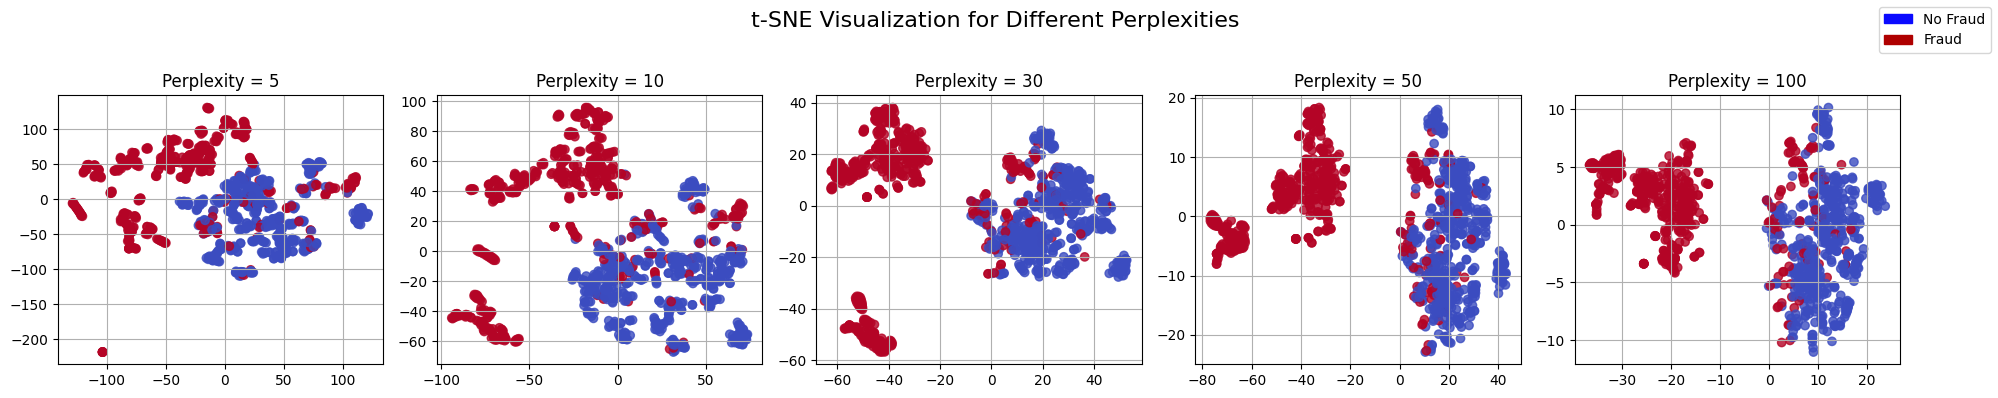

In [25]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd


perplexities = [5, 10, 30, 50, 100]

fig, axes = plt.subplots(1, len(perplexities), figsize=(20, 4))
fig.suptitle('t-SNE Visualization for Different Perplexities', fontsize=16)

blue_patch = mpatches.Patch(color='#0A0AFF', label='No Fraud')
red_patch = mpatches.Patch(color='#AF0000', label='Fraud')

for i, p in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=p, max_iter=4000, random_state=42)
    x_reduced = tsne.fit_transform(x_undersample.values)

    ax = axes[i]
    ax.set_title(f'Perplexity = {p}', fontsize=12)

    # Plot only once with color labels
    scatter = ax.scatter(
        x_reduced[:, 0], x_reduced[:, 1],
        c=y_undersample.values,
        cmap='coolwarm',
        linewidths=1,
        alpha=0.8
    )
    ax.grid(True)

# Add a single legend
fig.legend(handles=[blue_patch, red_patch], loc='upper right')
plt.tight_layout(rect=[0, 0, 0.96, 0.95])
plt.show()


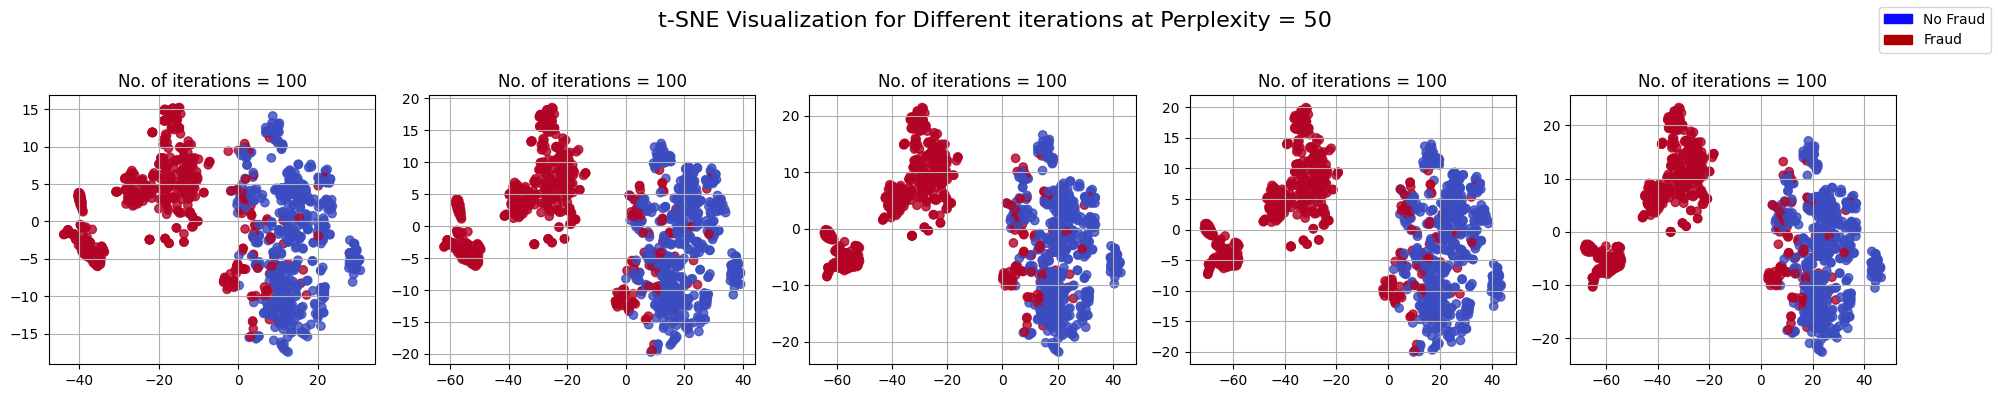

In [28]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd


iter = [500, 1000, 2000, 3000, 5000]

fig, axes = plt.subplots(1, len(iter), figsize=(20, 4))
fig.suptitle('t-SNE Visualization for Different iterations at Perplexity = 50', fontsize=16)

blue_patch = mpatches.Patch(color='#0A0AFF', label='No Fraud')
red_patch = mpatches.Patch(color='#AF0000', label='Fraud')

for i, iter in enumerate(iter):
    tsne = TSNE(n_components=2, perplexity=50, max_iter=iter)
    x_reduced = tsne.fit_transform(x_undersample.values)

    ax = axes[i]
    ax.set_title(f'No. of iterations = {p}', fontsize=12)

    # Plot only once with color labels
    scatter = ax.scatter(
        x_reduced[:, 0], x_reduced[:, 1],
        c=y_undersample.values,
        cmap='coolwarm',
        linewidths=1,
        alpha=0.8
    )
    ax.grid(True)

# Add a single legend
fig.legend(handles=[blue_patch, red_patch], loc='upper right')
plt.tight_layout(rect=[0, 0, 0.96, 0.95])
plt.show()


#Interpretation:
1. The t-SNE plot supports that the classes are separable, which is great for  machine learning.

2. It confirms that there is underlying structure in the feature space that can help you classify fraudulent vs. non-fraudulent transactions.

3. It also warns that not all frauds are distinct — some appear embedded within non-fraud clusters, meaning you might need robust models (e.g., ensemble or anomaly detection).

In [ ]:
#Now let's start with training models to see their accuracy scores and the probably we can do some more feature engineering